# Solving the 1D Heat Equation with a Physics-Informed Neural Network

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Companion/cc01_pinn/pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

Physics-informed neural networks (PINNs) combine data and physical knowledge within a single learning framework. In this notebook, you'll use a PINN to solve the one-dimensional heat equation, a fundamental model of diffusion and heat transport. You'll see how automatic differentiation allows a neural network to satisfy a differential equation, compare the learned solution with a numerical reference solution, and investigate how physical constraints help reconstruct the dynamics from limited observations.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This companion example extends several ideas introduced throughout the book, specifically, Chapter 2 (neural networks as function approximators) and Chapter 11 (learning physical systems). Unlike the examples in the book, the network is trained not only from data but also from the governing physical equation.

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Understanding Physics-Informed Neural Networks

Many scientific and engineering problems are governed by known physical laws. For example, heat diffuses through a material according to the heat equation, planets move according to Newton's laws, and electrical circuits obey Maxwell's equations. When solving these problems, you often have two sources of information: observations collected from experiments or simulations; and physical laws describing how the system evolves.

Traditional machine-learning models typically rely only on data. Given enough examples, a neural network can learn to approximate the relationship between inputs and outputs. However, in many scientific applications, collecting large amounts of data can be expensive, time-consuming, or even impossible. At the same time, you often possess valuable prior knowledge in the form of differential equations.

Physics-informed neural networks (PINNs) combine these two sources of information. Instead of training a neural network solely to match observed data, we also require it to satisfy the governing physical equations.

### Defining the Problem

Suppose you want a neural network to approximate a function
$$
u(x,t)
$$
where $x$ denotes position and $t$ denotes time. The network should take $(x,t)$ as input and predict the value of the solution at that point.

### Fitting the Observed Data

In a conventional supervised-learning setting, you train the network using observed values of the solution. If you have measurements
$$
\{(x_i, t_i, u_i)\}_{i=1}^{N}
$$
you can compare the network prediction
$$
u_\theta(x_i,t_i)
$$
with the observed value $u_i$.

The corresponding data loss is
$$
\mathcal{L}_{\text{data}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u_\theta(x_i,t_i) - u_i
\right)^2
$$
Minimizing this loss encourages the network to reproduce the available observations.

However, if only a small number of observations are available, many different functions may fit the data equally well. Nothing prevents the network from producing physically unrealistic solutions between the observed points.


### Enforcing the Physical Law

Now suppose that the solution must satisfy a differential equation of the form
$$
F\!\left(
x,
t,
u,
\frac{\partial u}{\partial t},
\frac{\partial u}{\partial x},
\frac{\partial^2 u}{\partial x^2},
\ldots
\right)
=
0
$$

If the neural network predicts the correct solution, substituting its output into the differential equation should give a value close to zero everywhere in the domain.

You can therefore define the PDE residual
$$
r(x,t)
=
F\!\left(
x,
t,
u_\theta,
\frac{\partial u_\theta}{\partial t},
\frac{\partial u_\theta}{\partial x},
\frac{\partial^2 u_\theta}{\partial x^2},
\ldots
\right)
$$
which measures how strongly the network violates the governing equation.

The physics loss is then
$$
\mathcal{L}_{\text{physics}}
=
\frac{1}{M}
\sum_{j=1}^{M}
r(x_j,t_j)^2
$$
where the points $(x_j,t_j)$ are sampled throughout the domain.

Minimizing this loss encourages the network to satisfy the physical law, even in regions where no observations are available.

### Combining Data and Physics

A PINN combines the two objectives into a single loss function:
$$
\mathcal{L}
=
\mathcal{L}_{\text{data}}
+
\lambda
\mathcal{L}_{\text{physics}}
$$
where $\lambda$ controls the relative importance of fitting the observations and satisfying the physical equation.

The data loss answers the question:

> Does the solution match the observations?

The physics loss answers a different question:

> Does the solution obey the governing physical law?

A good PINN must satisfy both requirements simultaneously.

The key ingredient that makes PINNs possible is automatic differentiation. Because a neural network is a differentiable function, PyTorch can compute derivatives of the network output with respect to its inputs.

For example, if the network predicts
$$
u_\theta(x,t)
$$
PyTorch can automatically evaluate quantities such as
$$
\frac{\partial u_\theta}{\partial t},
\qquad
\frac{\partial u_\theta}{\partial x},
\qquad
\frac{\partial^2 u_\theta}{\partial x^2}
$$
which can then be substituted directly into the differential equation.

## Introducing the Heat Equation

The heat equation describes how heat diffuses through a material over time. It is one of the most important partial differential equations in physics and engineering, appearing in applications ranging from heat transfer and fluid dynamics to diffusion processes in biology and chemistry.

In one spatial dimension, the heat equation can be written as
$$
\frac{\partial u}{\partial t}
=
D
\frac{\partial^2 u}{\partial x^2}
$$
where $u(x,t)$ is the temperature at position $x$ and time $t$; $D$ is the diffusion coefficient $\frac{\partial u}{\partial t}$ describes how the temperature changes over time; and $\frac{\partial^2 u}{\partial x^2}$ measures the curvature of the temperature profile.

The equation states that heat flows from warmer regions to cooler regions, gradually smoothing out temperature differences.

In this notebook, you'll consider a rod of length 1 with fixed temperatures at both ends:
$$
u(0,t)=0
\qquad
u(1,t)=0
$$

You'll also specify an initial temperature distribution,
$$
u(x,0)=\sin(\pi x)
$$
which creates a temperature peak in the middle of the rod.

As time passes, heat diffuses toward the boundaries and the temperature profile gradually flattens.

To evaluate your PINN later, you'll first generate a reference solution using a conventional numerical method.

### Generating a Reference Solution

Before training a neural network, you should generate a reference solution that represents the true behavior of the system.

You'll solve the heat equation on a discrete grid using a finite-difference method. This gives you the temperature $u(x,t)$ at all positions and times. Later, you'll sample only a few of these points as observations and use the full solution only for evaluation.

Initialize the numercial solution parameters and check its stability ...

In [1]:
import numpy as np

# Physical and numerical parameters.
D = 0.1

x_min, x_max, num_x = 0.0, 1.0, 101
x = np.linspace(x_min, x_max, num_x)
dx = x[1] - x[0]

t_min, t_max, num_t = 0.0, 1.0, 2001
t = np.linspace(t_min, t_max, num_t)
dt = t[1] - t[0]

alpha = D * dt / dx ** 2
print(f"Stability parameter alpha = {alpha:.3f}")

if alpha > 0.5:
    raise ValueError(
        "The finite-difference scheme is unstable. Reduce dt or increase dx."
    )

Stability parameter alpha = 0.500


... and calculate the solution.

In [2]:
# Initialize the solution array.
u = np.zeros((num_t, num_x))

# Initial condition: u(x, 0) = sin(pi x).
u[0, :] = np.sin(np.pi * x)

# Boundary conditions: u(0, t) = u(1, t) = 0.
u[:, 0] = 0.0
u[:, -1] = 0.0

# Explicit finite-difference update.
for n in range(num_t - 1):
    u[n + 1, 1:-1] = (
        u[n, 1:-1]
        + alpha * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
    )

### Visualizing the Solution

Before training any model, it's important to inspect the data.

The heat equation produces a smooth diffusion process. Initially, the temperature is concentrated near the center of the rod. Over time, the temperature decreases and the profile becomes flatter.

By plotting a heatmap, you can see how the temperature evolves over time ...

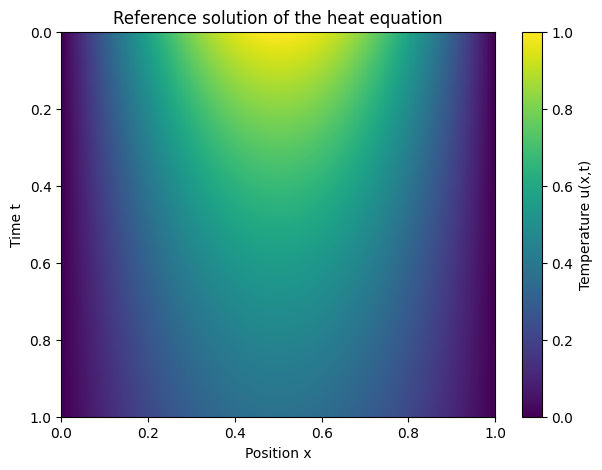

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.imshow(
    u,
    extent=[x_min, x_max, t_max, t_min],
    aspect="auto",
)
plt.colorbar(label="Temperature u(x,t)")
plt.xlabel("Position x")
plt.ylabel("Time t")
plt.title("Reference solution of the heat equation")
plt.show()

... and, by plotting the individual profiles, you can see the same process as a sequence of curves: the initial peak gradually decays as heat diffuses through the rod.

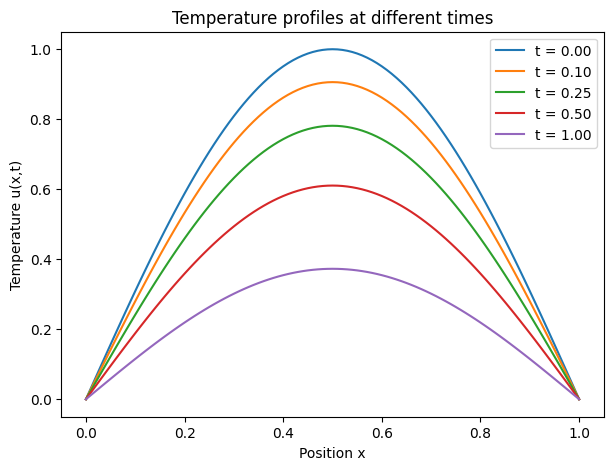

In [4]:
plt.figure(figsize=(7, 5))

for time_value in [0.0, 0.1, 0.25, 0.5, 1.0]:
    time_index = np.argmin(np.abs(t - time_value))
    plt.plot(x, u[time_index], label=f"t = {t[time_index]:.2f}")

plt.xlabel("Position x")
plt.ylabel("Temperature u(x,t)")
plt.title("Temperature profiles at different times")
plt.legend()
plt.show()

Your goal will be to recover this full space-time solution using a neural network trained on only a small subset of observations.

### Sampling Sparse Observations

In real scientific applications, you rarely observe the full solution of a system. Measurements may be expensive, noisy, or available only at a few locations and times.

To mimic this situation, you'll randomly sample a small number of points from the reference solution and treat them as the available observations.

The PINN will use these sparse observations together with the heat equation during training.

Start by selecting a few points from the simulated ones ...

In [5]:
rng = np.random.default_rng(seed=42)

# Create a grid of all space-time coordinates.
T, X = np.meshgrid(t, x, indexing="ij")

x_all = X.reshape(-1, 1)
t_all = T.reshape(-1, 1)
u_all = u.reshape(-1, 1)

# Sample sparse observations.
num_observations = 10
sample_indices = rng.choice(len(x_all), size=num_observations, replace=False)

x_obs = x_all[sample_indices]
t_obs = t_all[sample_indices]
u_obs = u_all[sample_indices]

print("x_obs shape:", x_obs.shape)
print("t_obs shape:", t_obs.shape)
print("u_obs shape:", u_obs.shape)

x_obs shape: (10, 1)
t_obs shape: (10, 1)
u_obs shape: (10, 1)


... you can plot these as black points to mark the observations available to the neural network.

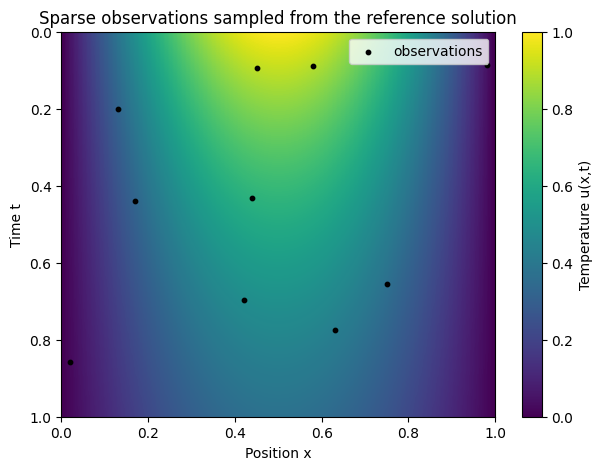

In [6]:
plt.figure(figsize=(7, 5))
plt.imshow(
    u,
    extent=[x_min, x_max, t_max, t_min],
    aspect="auto",
)
plt.scatter(x_obs, t_obs, s=10, c="k", label="observations")
plt.colorbar(label="Temperature u(x,t)")
plt.xlabel("Position x")
plt.ylabel("Time t")
plt.title("Sparse observations sampled from the reference solution")
plt.legend()
plt.show()

Large parts of the domain remain unobserved. A conventional neural network must infer the solution between these points using data alone. A physics-informed neural network also uses the heat equation, which provides information throughout the domain even where no measurements are available.

## Building a Physics-Informed Neural Network

A physics-informed neural network represents the solution of the differential equation with a neural network. Instead of predicting a discrete set of values on a grid, the network learns a continuous function
$$
u_\theta(x,t)
$$
which maps any position $x$ and time $t$ to a predicted temperature.

This approach differs from conventional numerical methods. Rather than storing the solution at individual grid points, the neural network acts as a differentiable approximation of the entire solution field.

To build this model, you'll use Deeplay to define a simple multilayer perceptron. The network takes two inputs, position and time, and outputs a single temperature value.

### Creating the Neural Network

The first step is to create the neural network that will represent the unknown solution. Since the solution depends on position and time, the network receives two inputs and returns one output:
$$
(x,t) \longrightarrow u_\theta(x,t)
$$

For PINNs, smooth activation functions are useful because the training process requires derivatives of the network output. Here, you'll use hyperbolic tangent activations in the hidden layers and a linear output layer.

In [7]:
import deeplay as dl
import torch

torch.manual_seed(42)

model = dl.MultiLayerPerceptron(
    in_features=2,
    hidden_features=[64, 64, 64],
    out_features=1,
    out_activation=torch.nn.Identity,
)

model["blocks", :-1, "activation"].configure(torch.nn.Tanh)

model = model.create()

print(model)
print(f"{sum(p.numel() for p in model.parameters())} trainable parameters")

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Linear(in_features=2, out_features=64, bias=True)
      (activation): Tanh()
    )
    (1-2): 2 x LinearBlock(
      (layer): Linear(in_features=64, out_features=64, bias=True)
      (activation): Tanh()
    )
    (3): LinearBlock(
      (layer): Linear(in_features=64, out_features=1, bias=True)
      (activation): Identity()
    )
  )
)
8577 trainable parameters


### Preparing the Data

The sparse observations are still stored as NumPy arrays. To train the neural network, you need to convert them into PyTorch tensors.

In [8]:
x_obs_tensor = torch.tensor(x_obs, dtype=torch.float32)
t_obs_tensor = torch.tensor(t_obs, dtype=torch.float32)
u_obs_tensor = torch.tensor(u_obs, dtype=torch.float32)

x_all_tensor = torch.tensor(x_all, dtype=torch.float32)
t_all_tensor = torch.tensor(t_all, dtype=torch.float32)
u_all_tensor = torch.tensor(u_all, dtype=torch.float32)

print("x_obs_tensor shape:", x_obs_tensor.shape)
print("t_obs_tensor shape:", t_obs_tensor.shape)
print("u_obs_tensor shape:", u_obs_tensor.shape)

x_obs_tensor shape: torch.Size([10, 1])
t_obs_tensor shape: torch.Size([10, 1])
u_obs_tensor shape: torch.Size([10, 1])


You also need a set of collocation points. These are points in the space-time domain where no observed temperature value is provided. They are used only to check whether the neural network satisfies the heat equation.

In [9]:
num_collocation = 5000

x_col = torch.rand((num_collocation, 1), dtype=torch.float32)
t_col = torch.rand((num_collocation, 1), dtype=torch.float32)

print("x_col shape:", x_col.shape)
print("t_col shape:", t_col.shape)

x_col shape: torch.Size([5000, 1])
t_col shape: torch.Size([5000, 1])


### Passing the Data to the Neural Network

The network expects one input tensor with two columns. The first column contains the position $x$, and the second contains the time $t$.

In [10]:
xt_obs = torch.cat([x_obs_tensor, t_obs_tensor], dim=1)

with torch.no_grad():
    u_p = model(xt_obs)

print("Input shape:", xt_obs.shape)
print("Output shape:", u_p.shape)

Input shape: torch.Size([10, 2])
Output shape: torch.Size([10, 1])


The model returns one predicted temperature value for each input point. Since the model has not been trained yet, these predictions are not meaningful. They only confirm that the network has the correct input and output structure.

### Computing the Derivatives

To enforce the heat equation, you need the derivatives
$$
\frac{\partial u_\theta}{\partial t}
\qquad \text{and} \qquad
\frac{\partial^2 u_\theta}{\partial x^2}
$$

PyTorch can compute these derivatives automatically. To do this, the input tensors must have `requires_grad=True`, which tells PyTorch to track the operations applied to them.

In [11]:
def derivative(y, x):
    """Compute dy/dx."""
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
    )[0]

In [12]:
x_test = torch.tensor([[0.25], [0.50], [0.75]], requires_grad=True)
t_test = torch.tensor([[0.10], [0.10], [0.10]], requires_grad=True)

xt_test = torch.cat([x_test, t_test], dim=1)

u_test = model(xt_test)

du_dx = derivative(u_test, x_test)
du_dt = derivative(u_test, t_test)
d2u_dx2 = derivative(du_dx, x_test)

print("u_test shape:", u_test.shape)
print("du_dx shape:", du_dx.shape)
print("du_dt shape:", du_dt.shape)
print("d2u_dx2 shape:", d2u_dx2.shape)

u_test shape: torch.Size([3, 1])
du_dx shape: torch.Size([3, 1])
du_dt shape: torch.Size([3, 1])
d2u_dx2 shape: torch.Size([3, 1])


The important point is that these derivatives are not computed by finite differences. They are computed directly from the differentiable neural network. This is what allows the physical equation to become part of the training objective.

### Using the Derivatives to Define the Residual

For the one-dimensional heat equation,
$$
\frac{\partial u}{\partial t}
=
D
\frac{\partial^2 u}{\partial x^2}
$$
the residual is
$$
r(x,t)
=
\frac{\partial u_\theta}{\partial t}
-
D
\frac{\partial^2 u_\theta}{\partial x^2}
$$
If the neural network satisfies the heat equation exactly, this residual is zero everywhere.

In [13]:
def heat_equation_residual(model, x, t, D):
    """Compute the residual of the 1D heat equation."""
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    xt = torch.cat([x, t], dim=1)

    u_p = model(xt)

    du_dt = derivative(u_p, t)
    du_dx = derivative(u_p, x)
    d2u_dx2 = derivative(du_dx, x)

    residual = du_dt - D * d2u_dx2

    return residual

In [14]:
residual = heat_equation_residual(model, x_col, t_col, D)

print("Residual shape:", residual.shape)
print("Mean squared residual:", torch.mean(residual ** 2).item())

Residual shape: torch.Size([5000, 1])
Mean squared residual: 5.594717731582932e-05


Because the model is still untrained, the residual is not expected to be small. During training, the physics-informed part of the loss will penalize this residual and push the network toward solutions that satisfy the heat equation.

### Building the Physics-Informed Loss

The PINN loss has two terms. The data loss compares the network predictions with the sparse observations:
$$
\mathcal{L}_{\mathrm{data}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u_\theta(x_i,t_i)-u_i
\right)^2
$$

The physics loss penalizes violations of the heat equation at the collocation points:
$$
\mathcal{L}_{\mathrm{physics}}
=
\frac{1}{M}
\sum_{j=1}^{M}
r(x_j,t_j)^2
$$

The total loss is
$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{data}}
+
\lambda
\mathcal{L}_{\mathrm{physics}}
$$

In [15]:
mse = torch.nn.MSELoss()

def pinn_loss(
    model,
    x_data,
    t_data,
    u_data,
    x_col,
    t_col,
    D,
    lambda_physics=1.0,
):
    """Compute the total PINN loss."""
    xt_data = torch.cat([x_data, t_data], dim=1)

    u_p = model(xt_data)

    data_loss = mse(u_p, u_data)

    residual = heat_equation_residual(model, x_col, t_col, D)

    physics_loss = torch.mean(residual ** 2)

    loss = data_loss + lambda_physics * physics_loss

    return loss, data_loss, physics_loss

In [16]:
loss, data_loss, physics_loss = pinn_loss(
    model,
    x_obs_tensor,
    t_obs_tensor,
    u_obs_tensor,
    x_col,
    t_col,
    D,
)

print(f"Total loss: {loss.item():.6f}")
print(f"Data loss: {data_loss.item():.6f}")
print(f"Physics loss: {physics_loss.item():.6f}")

Total loss: 0.229590
Data loss: 0.229534
Physics loss: 0.000056


This loss function is the central object of the PINN. The data loss anchors the solution to the available observations, while the physics loss constrains the solution between observations by enforcing the heat equation throughout the domain.

In the next section, you'll train the model by minimizing this combined loss.

## Training the PINN

You can now train the physics-informed neural network by minimizing the combined loss. At each iteration, the network is asked to do two things:

1. match the sparse observations;
2. satisfy the heat equation at the collocation points.

The data loss anchors the solution to the available measurements, while the physics loss guides the prediction in the rest of the space-time domain.

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

num_epochs = 5000
lambda_physics = 1.0

pinn_losses = []
pinn_data_losses = []
pinn_physics_losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()

    loss, data_loss, physics_loss = pinn_loss(
        model,
        x_obs_tensor,
        t_obs_tensor,
        u_obs_tensor,
        x_col,
        t_col,
        D,
        lambda_physics=lambda_physics,
    )

    loss.backward()
    optimizer.step()

    pinn_losses.append(loss.item())
    pinn_data_losses.append(data_loss.item())
    pinn_physics_losses.append(physics_loss.item())

    if epoch % 500 == 0:
        print(
            f"epoch {epoch:4d} | "
            f"loss = {loss.item():.6f} | "
            f"data = {data_loss.item():.6f} | "
            f"physics = {physics_loss.item():.6f}"
        )

epoch    0 | loss = 0.229590 | data = 0.229534 | physics = 0.000056
epoch  500 | loss = 0.001881 | data = 0.000895 | physics = 0.000986
epoch 1000 | loss = 0.000110 | data = 0.000044 | physics = 0.000066
epoch 1500 | loss = 0.000044 | data = 0.000016 | physics = 0.000028
epoch 2000 | loss = 0.000026 | data = 0.000010 | physics = 0.000016
epoch 2500 | loss = 0.000019 | data = 0.000007 | physics = 0.000012
epoch 3000 | loss = 0.000016 | data = 0.000005 | physics = 0.000010
epoch 3500 | loss = 0.000013 | data = 0.000004 | physics = 0.000009
epoch 4000 | loss = 0.000012 | data = 0.000004 | physics = 0.000008
epoch 4500 | loss = 0.000011 | data = 0.000003 | physics = 0.000007


Plotting the losses helps verify that both terms contribute to training. The total loss should decrease, but the data and physics terms do not necessarily decrease at the same rate.

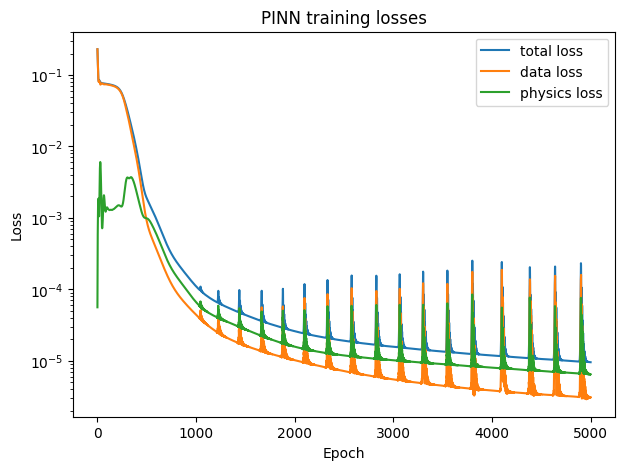

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(pinn_losses, label="total loss")
plt.plot(pinn_data_losses, label="data loss")
plt.plot(pinn_physics_losses, label="physics loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN training losses")
plt.legend()
plt.show()

## Training a Data-Only Network

To understand what the physics term contributes, you need a baseline. The data-only network has the same architecture as the PINN, but it is trained only to match the sparse observations. It does not know the heat equation.

In [19]:
def create_mlp():
    """Create a multilayer perceptron for u(x,t)."""
    model = dl.MultiLayerPerceptron(
        in_features=2,
        hidden_features=[64, 64, 64],
        out_features=1,
        out_activation=torch.nn.Identity,
    )

    model["blocks", :-1, "activation"].configure(torch.nn.Tanh)

    return model.create()

In [20]:
data_model = create_mlp()

optimizer = torch.optim.Adam(data_model.parameters(), lr=1e-4)

data_only_losses = []

xt_obs = torch.cat([x_obs_tensor, t_obs_tensor], dim=1)

for epoch in range(num_epochs):
    optimizer.zero_grad()

    u_p = data_model(xt_obs)
    loss = mse(u_p, u_obs_tensor)

    loss.backward()
    optimizer.step()

    data_only_losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss = {loss.item():.6f}")

epoch    0 | loss = 0.250129
epoch  500 | loss = 0.054119
epoch 1000 | loss = 0.005920
epoch 1500 | loss = 0.000311
epoch 2000 | loss = 0.000145
epoch 2500 | loss = 0.000066
epoch 3000 | loss = 0.000020
epoch 3500 | loss = 0.000003
epoch 4000 | loss = 0.000000
epoch 4500 | loss = 0.000000


The data-only network is optimized on the same observations as the PINN. If it performs worse away from the observed points, the difference is due to the missing physical constraint rather than to a different architecture.

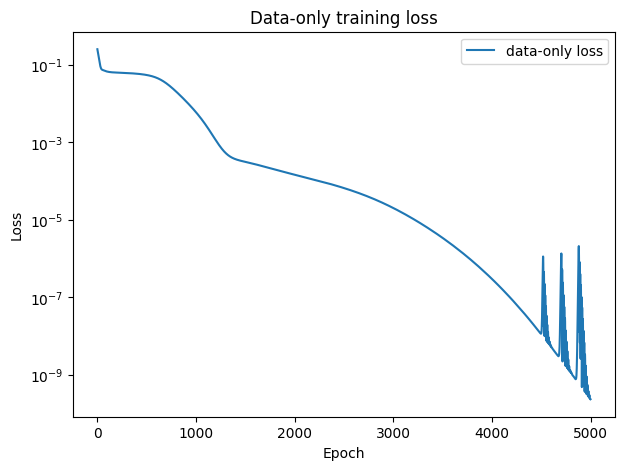

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(data_only_losses, label="data-only loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Data-only training loss")
plt.legend()
plt.show()

## Comparing the Learned Solutions

You can now evaluate both trained networks on the full space-time grid. This grid was not used as training data; it is used only to compare the learned solutions against the reference solution.

In [22]:
def predict_solution(model, x_values, t_values):
    """Evaluate a model on a full space-time grid."""
    T, X = np.meshgrid(t_values, x_values, indexing="ij")

    x_eval = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)
    t_eval = torch.tensor(T.reshape(-1, 1), dtype=torch.float32)

    xt_eval = torch.cat([x_eval, t_eval], dim=1)

    with torch.no_grad():
        u_p = model(xt_eval).numpy()

    return u_p.reshape(len(t_values), len(x_values))

In [23]:
u_pinn = predict_solution(model, x, t)
u_data_only = predict_solution(data_model, x, t)

pinn_rmse = np.sqrt(np.mean((u_pinn - u) ** 2))
data_only_rmse = np.sqrt(np.mean((u_data_only - u) ** 2))

print(f"PINN RMSE: {pinn_rmse:.6f}")
print(f"Data-only RMSE: {data_only_rmse:.6f}")

PINN RMSE: 0.004937
Data-only RMSE: 0.019390


The root mean squared error (RMSE) compares each learned solution with the reference solution over the full domain. A lower value indicates a better reconstruction.

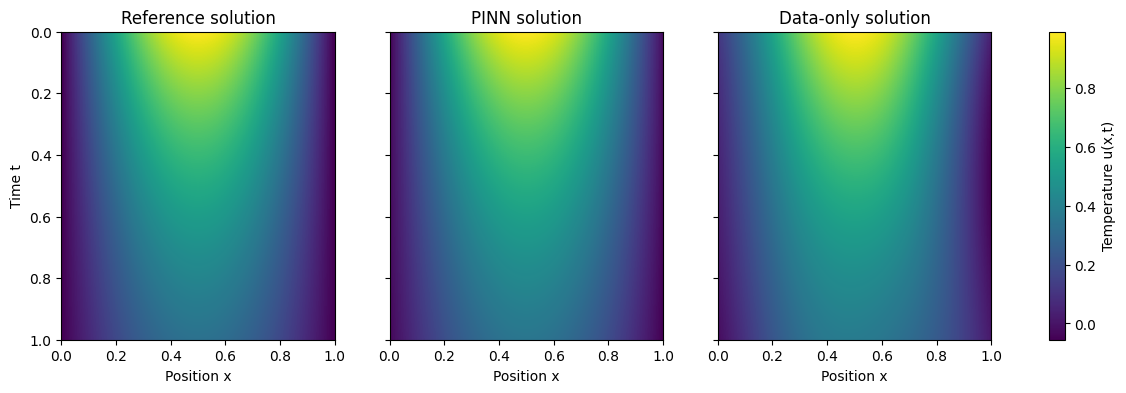

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

images = [
    (u, "Reference solution"),
    (u_pinn, "PINN solution"),
    (u_data_only, "Data-only solution"),
]

for ax, (image, title) in zip(axes, images):
    im = ax.imshow(
        image,
        extent=[x_min, x_max, t_max, t_min],
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Position x")

axes[0].set_ylabel("Time t")

fig.colorbar(im, ax=axes, label="Temperature u(x,t)")
plt.show()

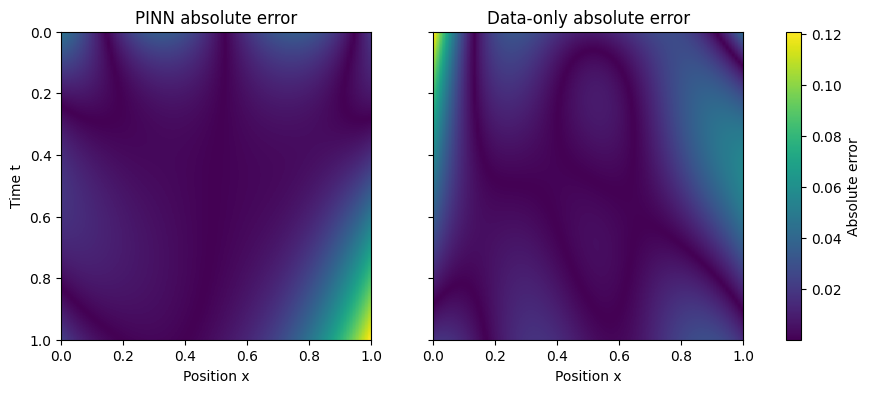

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

error_pinn = np.abs(u_pinn - u)
error_data_only = np.abs(u_data_only - u)

errors = [
    (error_pinn, "PINN absolute error"),
    (error_data_only, "Data-only absolute error"),
]

for ax, (image, title) in zip(axes, errors):
    im = ax.imshow(
        image,
        extent=[x_min, x_max, t_max, t_min],
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Position x")

axes[0].set_ylabel("Time t")

fig.colorbar(im, ax=axes, label="Absolute error")
plt.show()

The heatmaps show whether each model reconstructs the global structure of the solution. The error maps show where each model fails. The data-only model may fit the sparse observations well while producing less reliable predictions in unobserved regions.

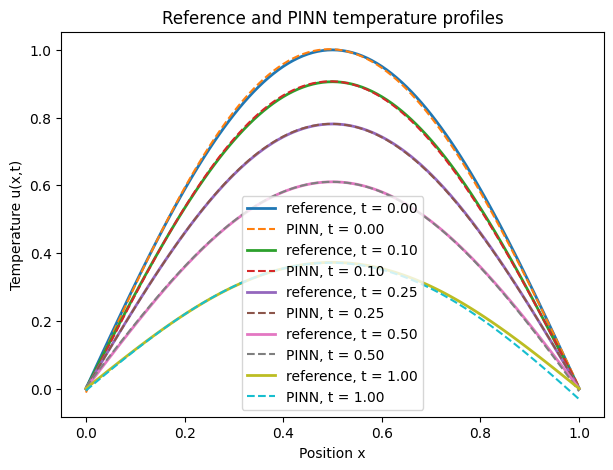

In [26]:
plt.figure(figsize=(7, 5))

for time_value in [0.0, 0.1, 0.25, 0.5, 1.0]:
    time_index = np.argmin(np.abs(t - time_value))

    plt.plot(
        x,
        u[time_index],
        linewidth=2,
        label=f"reference, t = {t[time_index]:.2f}",
    )
    plt.plot(
        x,
        u_pinn[time_index],
        linestyle="--",
        label=f"PINN, t = {t[time_index]:.2f}",
    )

plt.xlabel("Position x")
plt.ylabel("Temperature u(x,t)")
plt.title("Reference and PINN temperature profiles")
plt.legend()
plt.show()

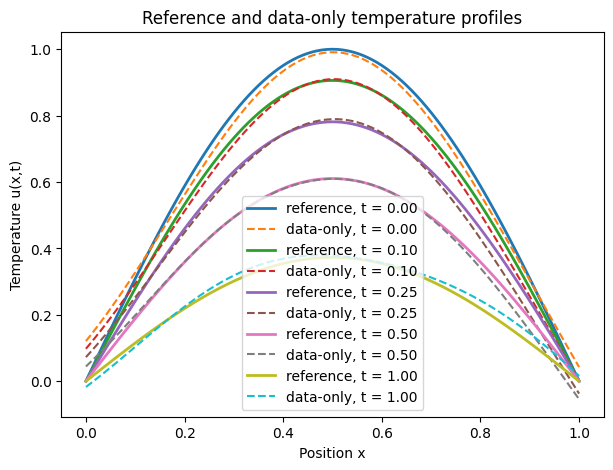

In [27]:
plt.figure(figsize=(7, 5))

for time_value in [0.0, 0.1, 0.25, 0.5, 1.0]:
    time_index = np.argmin(np.abs(t - time_value))

    plt.plot(
        x,
        u[time_index],
        linewidth=2,
        label=f"reference, t = {t[time_index]:.2f}",
    )
    plt.plot(
        x,
        u_data_only[time_index],
        linestyle="--",
        label=f"data-only, t = {t[time_index]:.2f}",
    )

plt.xlabel("Position x")
plt.ylabel("Temperature u(x,t)")
plt.title("Reference and data-only temperature profiles")
plt.legend()
plt.show()

The profile plots make the comparison more direct. The PINN should reproduce the smooth decay of the heat equation more consistently because the physics loss constrains the shape of the solution throughout the domain.

## Investigating Sparse-Data Performance

The advantage of PINNs is most visible when observations are scarce. To test this, you can repeat the training with different numbers of observations and compare the reconstruction error.

To keep the runtime manageable, this experiment uses fewer training epochs than the main training run.

## Understanding the Limitations of PINNs

PINNs are powerful, but they are not a universal replacement for numerical solvers or conventional machine-learning models.

First, PINNs can be difficult to optimize. The data loss and physics loss may have different scales, and the choice of the weight $\lambda$ can strongly affect training. If the physics term is too weak, the model behaves like a data-only network. If it is too strong, the model may satisfy the equation while failing to match the observations.

Second, PINNs require derivatives of the neural network output. This makes smooth activation functions useful, but it can also make training slower than ordinary supervised learning.

Third, the residual only enforces the differential equation at the sampled collocation points. If these points do not cover the domain well, the model may still produce inaccurate solutions in poorly sampled regions.

Finally, PINNs work best when the physical equation is known and correct. If the governing equation is incomplete, misspecified, or missing important effects, the physics loss can push the model toward the wrong solution.

In this notebook, the heat equation is simple, the data are noise-free, and the reference solution is easy to generate. Real scientific problems are usually harder: measurements may be noisy, parameters may be unknown, geometries may be complex, and the relevant physics may only be partially understood.

### Optimizing PINNs can be challenging

Training a PINN is often more difficult than training a standard neural network. The physics loss depends on derivatives of the network output and can introduce sharp curvature into the loss landscape. As a result, optimization may become unstable, especially when higher-order derivatives are involved.

During training, you may observe occasional spikes in the loss. These spikes typically occur when the optimizer takes a step that temporarily increases the residual of the differential equation before recovering. Such behavior is common in PINNs and reflects the complexity of balancing the data loss and the physics loss.

In practice, PINNs are often trained using a combination of optimizers. A common strategy is to train first with Adam to rapidly find a reasonable solution and then switch to L-BFGS, a second-order optimization method that often achieves better convergence for differential-equation problems.

The best optimization strategy depends on the specific problem, the neural-network architecture, and the governing equation.

## Exercises

The exercises below are organized into three groups. The first group explores variations of the notebook you have just completed. The second applies the same PINN methodology to new physical systems. The third points toward more advanced topics in scientific machine learning.

### Exploring the Current PINN

1. **Change the number of observations**

   Repeat the experiment with 5, 20, 50, and 100 observations. How does the reconstruction quality change for the PINN and the data-only neural network? At what point does the advantage of the PINN become less noticeable?

2. **Change the number of collocation points**

   Train the PINN with fewer and more collocation points. How does this affect the physics loss, the training time, and the quality of the reconstructed solution?

3. **Adjust the balance between data and physics**

   Experiment with different values of the physics-loss weight,

   $$
   \lambda_{\mathrm{physics}}.
   $$

   What happens when the physics term dominates the loss? What happens when it is too small?

4. **Add measurement noise**

   Add Gaussian noise to the observations before training. Compare the performance of the PINN and the data-only neural network. Does the physics constraint improve robustness to noisy measurements?

5. **Investigate the optimizer**

   During training, you may have observed occasional spikes in the loss. Repeat the experiment using a smaller learning rate and compare the resulting training curves. You can also try gradient clipping or switch from Adam to L-BFGS after a few hundred epochs. Which optimization strategy produces the most stable convergence?

6. **Change the network architecture**

   Increase or decrease the number of hidden layers and hidden units. How much model capacity is required to solve this problem accurately?

### Extending the Physical Problem

7. **Exponential decay**

   Replace the heat equation with

   $$
   \frac{du}{dt} = -ku.
   $$

   This is one of the simplest differential equations and provides a good introduction to PINNs based on ordinary differential equations.

8. **The harmonic oscillator**

   Solve

   $$
   \frac{d^2x}{dt^2} + \omega^2 x = 0.
   $$

   Compare the learned solution with the analytical sinusoidal solution.

9. **A different initial condition**

   Replace

   $$
   u(x,0)=\sin(\pi x)
   $$

   with a more complex temperature distribution. Does the same PINN architecture still learn the solution accurately?

10. **Learning an unknown physical parameter**

    Treat the diffusion coefficient (D) as a trainable parameter and attempt to recover its value from sparse observations. This is an example of an inverse problem, where the goal is not only to solve the equation but also to infer unknown properties of the system.

### Going Beyond This Notebook

11. **Burgers' equation**

    Replace the heat equation with Burgers' equation,

    $$
    \frac{\partial u}{\partial t}
    +
    u\frac{\partial u}{\partial x}
    =
    \nu\frac{\partial^2 u}{\partial x^2}.
    $$

    This is one of the classical benchmark problems for PINNs and introduces nonlinear dynamics.

12. **Learning a family of solutions**

    In this notebook, the PINN learns the solution of a single differential equation. Generate many heat-equation simulations with different initial conditions and investigate how one might learn an entire family of solutions rather than solving one instance at a time.

13. **Parameter discovery in scientific systems**

    Many scientific applications involve unknown parameters that cannot be measured directly. Explore how PINNs can be used to infer reaction rates, diffusion coefficients, or other physical parameters from sparse observations.

14. **From PINNs to Neural Operators**

    PINNs solve one physical system at a time. Neural operators, such as Fourier Neural Operators (FNOs), learn mappings between entire families of differential equations and can act as fast surrogate solvers. Investigate how neural operators differ from PINNs and what advantages they offer when many related simulations must be solved.


## Further Readings

Raissi, M., Perdikaris, P., and Karniadakis, G. E. (2019). Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. *Journal of Computational Physics*, 378, 686–707.

Karniadakis, G. E., Kevrekidis, I. G., Lu, L., Perdikaris, P., Wang, S., and Yang, L. (2021). Physics-informed machine learning. *Nature Reviews Physics*, 3, 422–440.